# Joseph's addition.

### Disclaimer to the marker.

Note my group did not ask for any of my input on the project despite my repeated asking about how I could help and barred me from making any changes to their submission of the model, and report. Not only this but removed my name from the project.

Thus this serves as a correction to their modelling, which was not well thoughtout and AI laden (in the unsupervised way).

### Central question of this addition.

I will focus on asking what is the total number of flu cases each week.

As a secondary predictions, I will use my prediction of total number of flu cases each week to try and predict the adjusted flu percentage rate and I will try to predict the number of non flu cases each week. In times of low flu cases for a particalar provider the provider will typically bother to submit the number of flu cases to the CDC.






## Data analysis:

### The data generation process

Providers collect the number of flu cases and each week submit this data to the CDC. Due to this being optional the number of providers fluctuates each week. Note if at any time we have no providers we will by definition have no flu cases being recorded.
This can be seen at various times such as during 1999 week 21 to 39. In which too flu cases were recorded by any providers to neccessitate reporting on the number of flu cases to the CDC. This does not mean that no flu cases were observed just that it was not reported.



### Structure of the data

We begin by noting that we have several count data points, thus a natural idea is to try and model these as poisson random variables with a rate parameter that fluctuates, for each of these processes. The problem is that we are unable to actaully observe the rate parameter aat each time.

Another notable thing about our data is the different age groups. The total number of recorded flu cases each week is split into several variables. That then are subdivide again in 2009 week 40 to account for a richer interpretation of the data.
What do I mean by this.


### Periods of interest

There are some periods when the number of flu cases drops or changes significantly, and the relationship in the data changes. This happens during three periods: Covid-19 pandemic, the 2009 sars pandemic, 0 counts flu period.

**Covid**-19

During Covid-19 many people were getting a flu related illness (Covid-19) but the number of non-related flulike visits drops off significantly as people weer social distancing and lockdowns were instituted. As such the percentage of flu related visits shoots up. A trend we would expect.

**SARs**

**Zero counts**

This is a really significant problem. Our data sometimes shows zero flu counts. This is actually just a censoring. In practice it may be different for each provider and the censoring rule for any particular provider may change over time and could also be slightly random. That being said we can try and approximate it. By looking at the number of flu counts per 




In [ ]:
# ACF, PACF, CCF

## Models

In the following document we used several models

### ARIMA

This model uses simply the ili_total as its data set, and seeks to predict the next ili_total. That is the total number of patients that would be at a hospital.




### Multiple ARIMA

In this we model each of the subgroups of the ili total with their onw ARIMA to determine if we can better predict the ili_total by better prediciting the individual subgroups.

### ARMAX

In this model we regress the  

### Multiple ARIMAX







### Translation of estimates to ILI_percentage and ILI_unweighted_percentage

This will be a bit of a nightmare but we can do it.
We want to manipulate our estimates of non_ili_total and ili_total to get our estimate of ili_unweighted_percentage. Then we will do a regression on that to get the ili_weighted_percentage. This will use linear exponential smoothing.

,X,ilitotal,percent_weighted_ili,percent_unweighted_ili,pw_trans,puw_trans,year,week,age_0_4,age_5_24,age_25_64,age_65,num_of_providers,non_ilitotal
,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,570,1.10148,1.21686,-4.409528,-4.316664,1997,40,5.192957,5.327876,5.062595,3.401197,5.262690,10.74231
2,2,615,1.20007,1.28064,-4.329666,-4.268720,1997,41,5.298317,5.493061,5.023881,3.178054,5.257495,10.76657
3,3,681,1.37876,1.23906,-4.199068,-4.299721,1997,42,5.433722,5.587249,5.036953,3.555348,5.393628,10.90193
4,4,653,1.19920,1.14473,-4.330344,-4.373726,1997,43,5.241747,5.468060,5.267858,3.610918,5.365976,10.94008
5,5,700,1.65618,1.26112,-4.024311,-4.283158,1997,44,5.384495,5.638355,5.093750,3.737670,5.365976,10.91157
6,6,655,1.41326,1.28275,-4.175656,-4.267172,1997,45,5.187386,5.641907,5.003946,3.891820,5.278115,10.82791


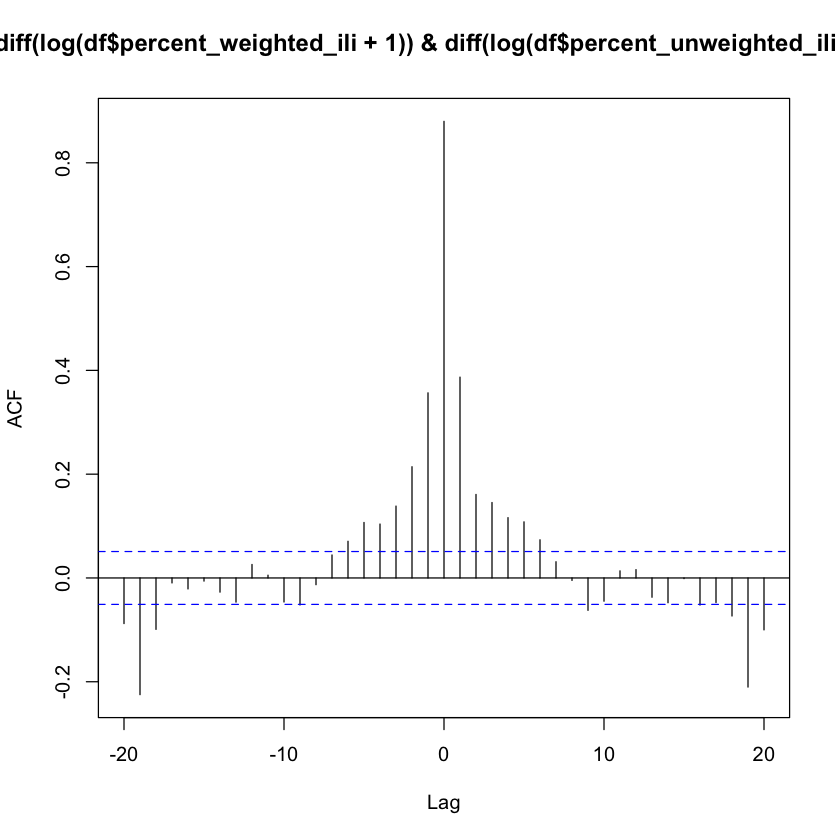

In [ ]:
df <- read.csv("data/fluview_clean/ilinet_final.csv")

head(df)
library(forecast)





In [28]:
# Fit ARIMAX: percent_weighted_ili ~ percent_unweighted_ili
library(forecast)

model_df <- df[, c("percent_weighted_ili", "percent_unweighted_ili")]
model_df <- model_df[complete.cases(model_df), ]

y <- ts(df$percent_weighted_ili-df$percent_unweighted_ili, frequency = 52)


# Use a faster search strategy for notebook execution
arima <- auto.arima(
  diff(y),
  seasonal = TRUE,
  stepwise = TRUE,
  approximation = TRUE
)
summary(arima)

Series: diff(y) 
ARIMA(0,0,1)(0,0,1)[52] with non-zero mean 

Coefficients:
          ma1    sma1    mean
      -0.2447  0.0881  0.0002
s.e.   0.0269  0.0279  0.0032

sigma^2 = 0.02327:  log likelihood = 684.46
AIC=-1360.92   AICc=-1360.89   BIC=-1339.72

Training set error measures:
                       ME      RMSE        MAE MPE MAPE      MASE        ACF1
Training set 1.177191e-05 0.1523984 0.08065633 NaN  Inf 0.7004958 0.009193094

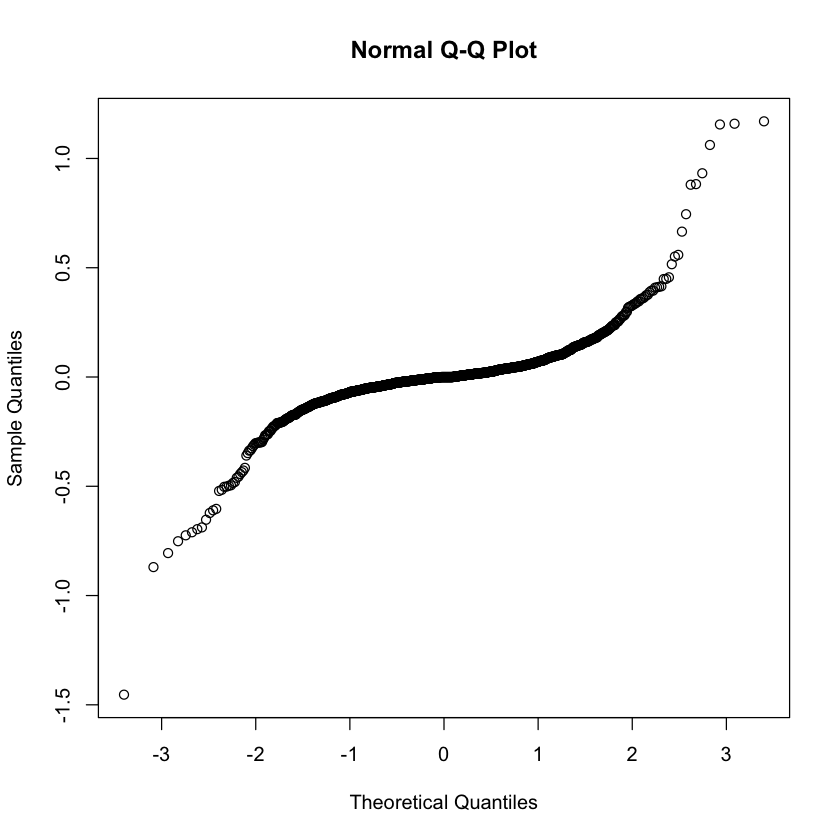

In [27]:
qqnorm(residuals(arimax_fit))


In [32]:
# # The holdout set is the last 104 weeks
# h <- 104

# # Calculate the RMSE for the 1-step-ahead rolling forecast on the training set
# # model_df <- df[, c("percent_weighted_ili", "percent_unweighted_ili")]
# # model_df <- model_df[complete.cases(model_df), ]

# n <- nrow(model_df)
# train_end <- n - h

# # if (train_end <= 105) stop("Not enough observations after reserving holdout set.")

# y_train <- model_df$percent_weighted_ili[1:train_end]
# x_train <- model_df$percent_unweighted_ili[1:train_end]

# y_train_ts <- ts(y_train, frequency = 52)
# x_train_mat <- matrix(x_train, ncol = 1)

# # Select ARIMAX structure once on the training set
# base_fit <- auto.arima(
#   y_train_ts,
#   xreg = x_train_mat,
#   seasonal = TRUE,
#   stepwise = TRUE,
#   approximation = TRUE
# )
# print(summary(base_fit))
# # # Expanding-window 1-step rolling forecasts (fixed ARIMA structure)
# # initial_window <- 104
# # idx <- seq(from = initial_window + 1, to = train_end)
# # errors <- numeric(length(idx))

# # for (k in seq_along(idx)) {
# #   i <- idx[k]

# #   fit_i <- Arima(
# #     ts(y_train[1:(i - 1)], frequency = 52),
# #     model = base_fit,
# #     xreg = matrix(x_train[1:(i - 1)], ncol = 1)
# #   )

# #   fc_i <- forecast(
# #     fit_i,
# #     h = 1,
# #     xreg = matrix(x_train[i], nrow = 1)
# #   )

# #   errors[k] <- y_train[i] - as.numeric(fc_i$mean[1])
# # }

# # rmse_train_1step <- sqrt(mean(errors^2, na.rm = TRUE))
# # rmse_train_1step

I want to build a model now that instead uses only the current and previous x value as well as the previous y value to predict the current y value

In [1]:
difference <- y_train - x_train
acf(difference, lag.max = 104)
pacf(difference, lag.max = 104)
arima_diff <- auto.arima(
  difference,
  seasonal = TRUE
)
summary(arima_diff)


# now wea want to do regression on this

ERROR: Error: object 'y_train' not found


Defining training data and 

In [ ]:

split_data <- function(df_column,frequency=52,start=c(1979,40),holdout_length=104){
  time_series_obj <-ts(df_column, frequency = frequency, start = start)
  n <- length(time_series_obj)
  return (list(
    train = window(time_series_obj, start=start, end=time(time_series_obj)[n-holdout_length]),
    holdout = window(time_series_obj, start=time(time_series_obj)[n-holdout_length+1], end=time(time_series_obj)[n]),
    ts_obj = time_series_obj
  ))
}

values <- split_data(log(df$percent_weighted_ili+1)-mean(log(df$percent_weighted_ili+1)))

weeks <- split_data(df$week,frequency = 52, start = c(1979,40), holdout_length = 104)

week_train = rep(1:12,18)
week_holdout = rep(1:12,5)
week_all = rep(1:12,23)
t_train = 1:length(values$train)
t_holdout = (length(values$train) + 1):(length(values$ts_obj))
t_all = 1:length(values$ts_obj)

percent_weighted_ili <- values$ts_obj

train <- values$train
holdout <- values$holdout



ERROR: Error in df$percent_weighted_ili: object of type 'closure' is not subsettable


In [116]:




arimax_fc <- function(tsdata,ntrain,order,method,traincoef,include.mean,xreg,
iprint=F){
    obj <<- arima(tsdata,order=order,init=traincoef,fixed=traincoef,
method=method, include.mean=include.mean, xreg=xreg,
optim.control=list(maxit=0))
    fc <- tsdata - obj$residuals
    n_total <- length(tsdata)
    holdout_fc <- fc[(ntrain+1):n_total]
    holdout <- tsdata[(ntrain+1):n_total]
    rmse <- sqrt(mean((holdout - holdout_fc)^2))
    list(rmse=rmse,fc = holdout_fc)
}

train_df <- data.frame(response = train, tt=t_train, cosine = cos(2 * pi * t_train / 52), sine = sin(2 * pi * t_train / 52))
holdout_df <- data.frame(response = holdout, tt=t_holdout, cosine = cos(2 * pi * t_holdout / 52), sine = sin(2 * pi * t_holdout / 52))
all_df <- data.frame(response = percent_weighted_ili,tt = t_all, cosine = cos(2 * pi * t_all / 52), sine = sin(2 * pi * t_all / 52))
reg_tt_cossin = lm(response~ tt+cosine+sine, data=train_df)
summary(reg_tt_cossin)


Call:
lm(formula = response ~ tt + cosine + sine, data = train_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.81428 -0.17154 -0.00459  0.13942  1.22070 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.661e-01  1.502e-02  -17.72   <2e-16 ***
tt           3.453e-04  1.887e-05   18.30   <2e-16 ***
cosine      -2.968e-01  1.061e-02  -27.96   <2e-16 ***
sine         3.790e-01  1.062e-02   35.70   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2786 on 1374 degrees of freedom
Multiple R-squared:  0.6351,	Adjusted R-squared:  0.6343 
F-statistic: 797.1 on 3 and 1374 DF,  p-value: < 2.2e-16


In [126]:

resid_reg = reg_tt_cossin$residuals
pred_holdout = predict(reg_tt_cossin, newdata=holdout_df)
(reg_rmse = sqrt(mean((holdout-pred_holdout)^2)))
# plot.ts(resid_reg)
arima_mod <-auto.arima(resid_reg[t_train], seasonal = TRUE)


[1] 0.2319541